# Hot-Dry and Hot-Wet Compound Events Calculation

Before you start running the code, it's important to select the kernel. To do this, click on Select Kernek in the upper right corner, choose Jupyter Kernel and then the R (compound) kernel.

In [1]:
library(loadeR)
library(transformeR)
library(visualizeR)

Loading required package: rJava

Loading required package: loadeR.java

Java version 23x amd64 by N/A detected

The maximum JVM heap space available is: 2.00 GB

NetCDF Java Library Version: 5.9.1.1 (Built-On: 2025-09-16T11:37:12-0600) loaded and ready

You can manually set the NetCDF Java Library version before loading the package:
options(loadeR.java_forced_version = "X.Y.Z")
library(loadeR.java)

netCDF-Java CLASSPATH from env LOADER_JAVA_CLASSPATH + bundled java package directory: /opt/conda/envs/compound/lib/java/toolsUI.jar:/opt/conda/envs/compound/lib/R/library/loadeR.java/java:/opt/conda/envs/compound/lib/R/library/loadeR.java/java/netcdfAll-4.6.0-SNAPSHOT.jar

Loading required package: climate4R.UDG

climate4R.UDG version 0.2.6 (2023-06-26) is loaded

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.8.4 (2025-08-07) is loaded

Please use 'citation("loadeR")' to cite this package.




    _______   ____  ___________________  __  ________ 
   / ___/ /  / /  |/  / __  /_  __/ __/ / / / / __  / 
  / /  / /  / / /|_/ / /_/ / / / / __/ / /_/ / /_/_/  
 / /__/ /__/ / /  / / __  / / / / /__ /___  / / \ \ 
 \___/____/_/_/  /_/_/ /_/ /_/  \___/    /_/\/   \_\ 
 
      github.com/SantanderMetGroup/climate4R



transformeR version 2.2.5 (2026-01-21) is loaded

Please see 'citation("transformeR")' to cite this package.

visualizeR version 1.6.4 (2023-10-26) is loaded

Please see 'citation("visualizeR")' to cite this package.



### Historical characterization (1986 - 2005)

In [2]:
pr.era5 <- readRDS("data/pr.era5.land.rds")
tmax.era5 <- readRDS("data/tasmax.era5.land.rds")

In [3]:
# We create a earth mask
mask <- climatology(tmax.era5)
mask$Data[!is.na(mask$Data)] <- 1

[2026-06-09 14:18:47.274548] - Computing climatology...

[2026-06-09 14:18:47.45444] - Done.



In [4]:
# Function to get the months from the mobile window
moving.window <- function(month) {
  months <- c((month-1)%%12, month%%12, (month+1)%%12)  # Previous, current, and next month
  months[months == 0] <- 12  # Corrects December (when (month-1)%%12 gives 0)
  return(sort(months))
}

tmax.vm <- list()

# We convert the diary data of tasmax in a estational cicle
suppressMessages(
  for(i in 1:12){
    tmax.month <- subsetGrid(tmax.era5, season=moving.window(i));
    tmax.month <- aggregateGrid(grid = tmax.month, aggr.y = list(FUN = "mean", na.rm = FALSE));
    tmax.clim <- climatology(tmax.month);
    tmax.vm[[i]] <- tmax.clim;
  }
)
tmax.estational.cicle <- do.call(bindGrid, c(tmax.vm, list(dimension = "time")));

In [5]:
source("functions/fun.hottest.season.R")
hottest.season <- fun.hottest.season(tmax.estational.cicle)

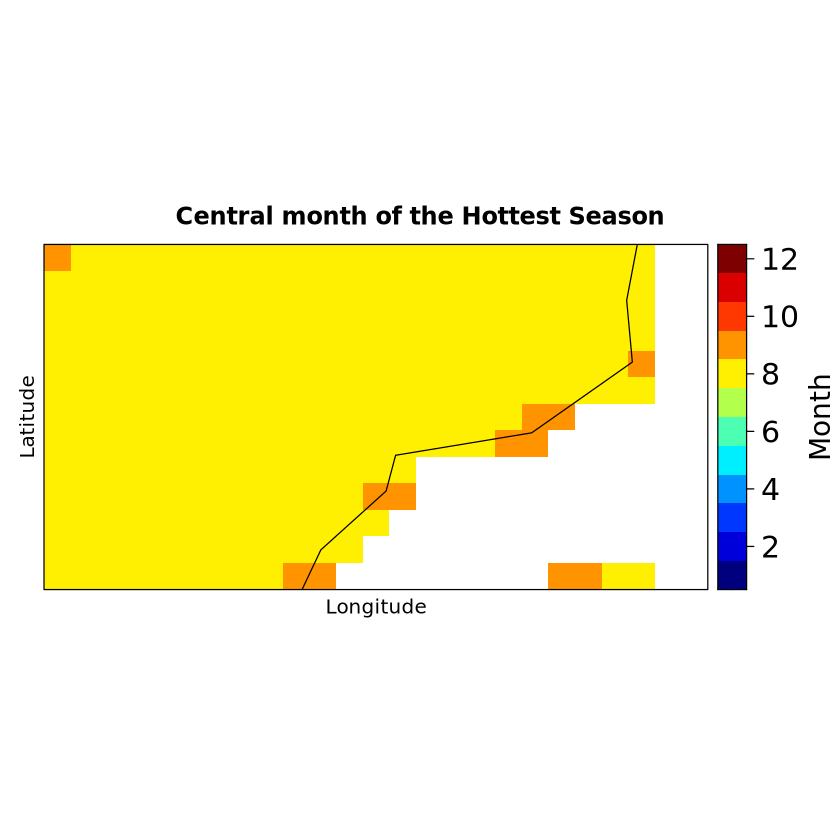

In [6]:
hs <- hottest.season
hs$Data <- hottest.season$Data[2,,]
attr(hs$Data, "dimensions") <- c("lat", "lon")

spatialPlot(hs, backdrop.theme = "coastline", 
            main=paste0("Central month of the Hottest Season"), 
            color.theme="jet.colors", set.min=0.5, set.max=12.5, at=seq(0.5,12.5,1),
            xlab="Longitude", ylab="Latitude",
            colorkey = list(space = "right",
                            title = list("Month", cex = 1.4),
                            labels = list(cex = 1.5)))

In [7]:
pr.isimip <- readRDS("data/pr.hist.baisimip.rds")
tmax.isimip <- readRDS("data/tasmax.hist.baisimip.rds")

In [8]:
# Processing data 
source("functions/fun.transform.data.R")
pr.isimip.tf <- transform.data(pr.isimip, hottest.season)
tmax.isimip.tf <- transform.data(tmax.isimip, hottest.season)

In [9]:
source("functions/fun.intensity.hw.hd.R")
intensity <- fun.intensity(pr.obs=pr.isimip.tf, tmax.obs=tmax.isimip.tf, tmax.daily=tmax.isimip.tf)

[2026-06-09 14:19:19.941463] - Computing climatology...

[2026-06-09 14:19:20.1236] - Done.

[2026-06-09 14:19:20.158023] - Computing climatology...

[2026-06-09 14:19:20.23832] - Done.



In [10]:
source("functions/fun.categories.intensity.mean.hw.hd.R")
suppressMessages(
  categories <- fun.categories(intensity)
)

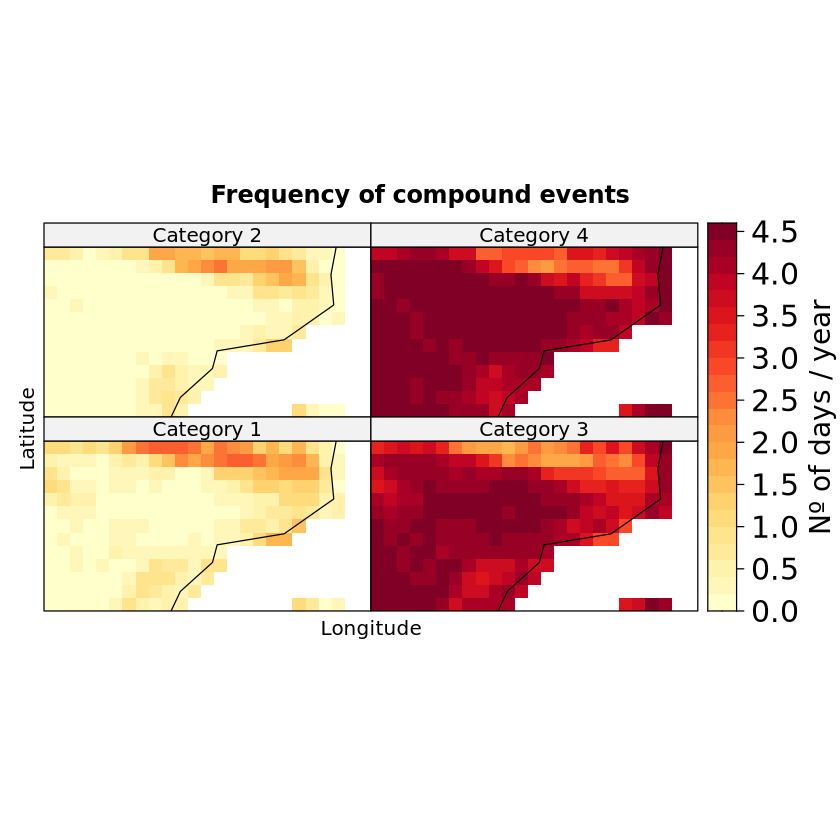

In [11]:
spatialPlot(makeMultiGrid(categories$c2, categories$c4, categories$c1, categories$c3), 
            backdrop.theme = "coastline", 
            main="Frequency of compound events", 
            as.table=TRUE, names.attr=c("Category 2", "Category 4", "Category 1", "Category 3"),
            color.theme="YlOrRd", set.min=0, set.max=4.6, at=seq(0,4.6,0.2),
            xlab="Longitude", ylab="Latitude",
            colorkey = list(space = "right",
                            title = list("Nº of days / year", cex = 1.4),
                            labels = list(cex = 1.5)))

In [12]:
source("functions/fun.duration.hw.hd.R")
suppressMessages(
  duration <- d.int(intensity)
)

[2026-06-09 14:23:21.613052] - Computing climatology...

[2026-06-09 14:23:21.617087] - Done.

[2026-06-09 14:23:21.621062] - Computing climatology...

[2026-06-09 14:23:21.624682] - Done.

[2026-06-09 14:23:21.629086] - Computing climatology...

[2026-06-09 14:23:21.633915] - Done.

[2026-06-09 14:23:21.639821] - Computing climatology...

[2026-06-09 14:23:21.644824] - Done.



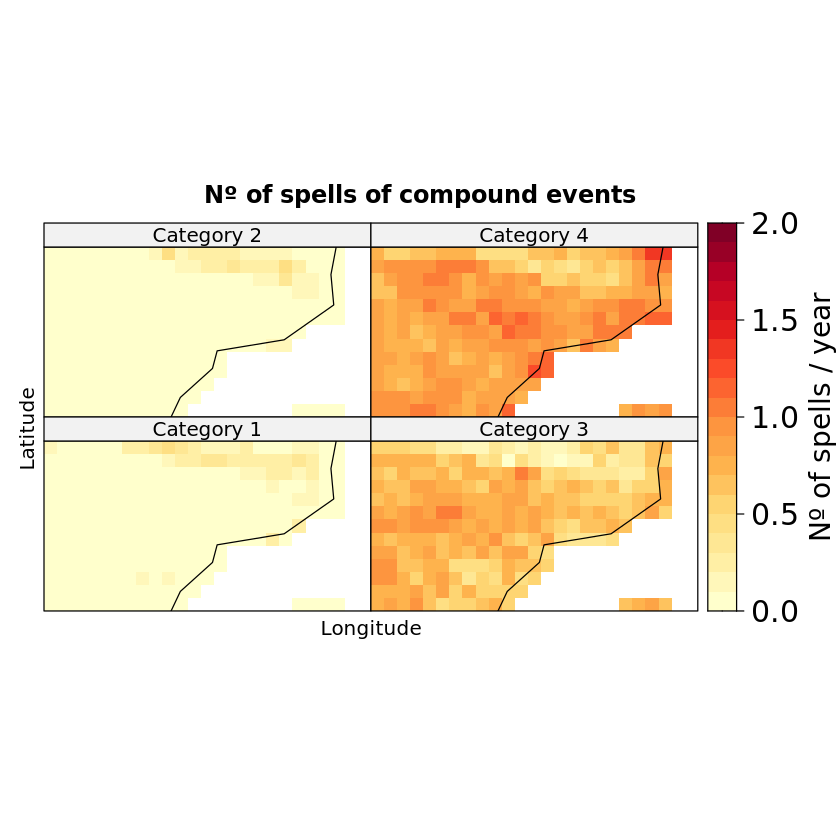

In [13]:
spatialPlot(makeMultiGrid(climatology(duration$num$c2), climatology(duration$num$c4), climatology(duration$num$c1), climatology(duration$num$c3)), 
            backdrop.theme = "coastline", 
            main="Nº of spells of compound events", 
            as.table=TRUE, names.attr=c("Category 2", "Category 4", "Category 1", "Category 3"),
            color.theme="YlOrRd", set.min=0, set.max=2, at=seq(0,2, 0.1),
            xlab="Longitude", ylab="Latitude",
            colorkey = list(space = "right",
                            title = list("Nº of spells / year", cex = 1.4),
                            labels = list(cex = 1.5)))

[2026-06-09 14:23:22.265676] - Computing climatology...

[2026-06-09 14:23:22.272835] - Done.

[2026-06-09 14:23:22.277578] - Computing climatology...

[2026-06-09 14:23:22.286825] - Done.

[2026-06-09 14:23:22.291356] - Computing climatology...

[2026-06-09 14:23:22.297586] - Done.

[2026-06-09 14:23:22.300826] - Computing climatology...

[2026-06-09 14:23:22.305842] - Done.



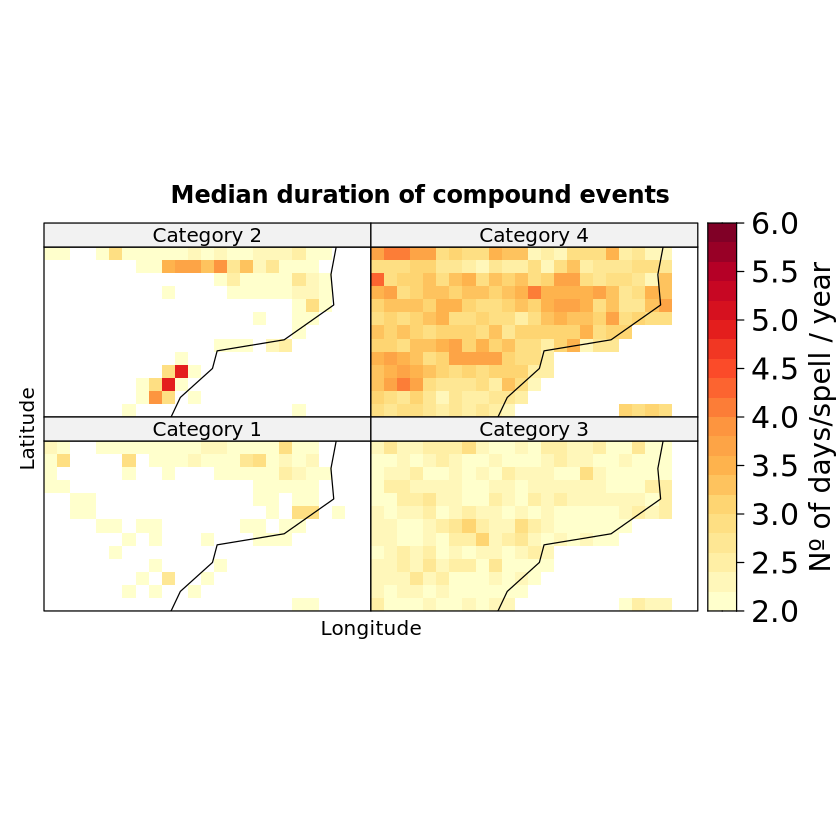

In [14]:
spatialPlot(makeMultiGrid(climatology(duration$median$c2), climatology(duration$median$c4), climatology(duration$median$c1), climatology(duration$median$c3)), 
            backdrop.theme = "coastline", 
            main="Median duration of compound events", 
            as.table=TRUE, names.attr=c("Category 2", "Category 4", "Category 1", "Category 3"),
            color.theme="YlOrRd", set.min=2, set.max=6, at=seq(2, 6, 0.2),
            xlab="Longitude", ylab="Latitude",
            colorkey = list(space = "right",
                            title = list("Nº of days/spell / year", cex = 1.4),
                            labels = list(cex = 1.5)))

In [15]:
source("functions/fun.magnitude.R")
magnitude <- fun.magnitude(intensity, tmax.isimip.tf)

[2026-06-09 14:23:26.887732] - Computing climatology...

[2026-06-09 14:23:26.967584] - Done.

[2026-06-09 14:23:26.995344] - Computing climatology...

[2026-06-09 14:23:27.02988] - Done.

[2026-06-09 14:23:27.050099] - Computing climatology...

[2026-06-09 14:23:27.092534] - Done.

[2026-06-09 14:23:27.113123] - Computing climatology...

[2026-06-09 14:23:27.153883] - Done.



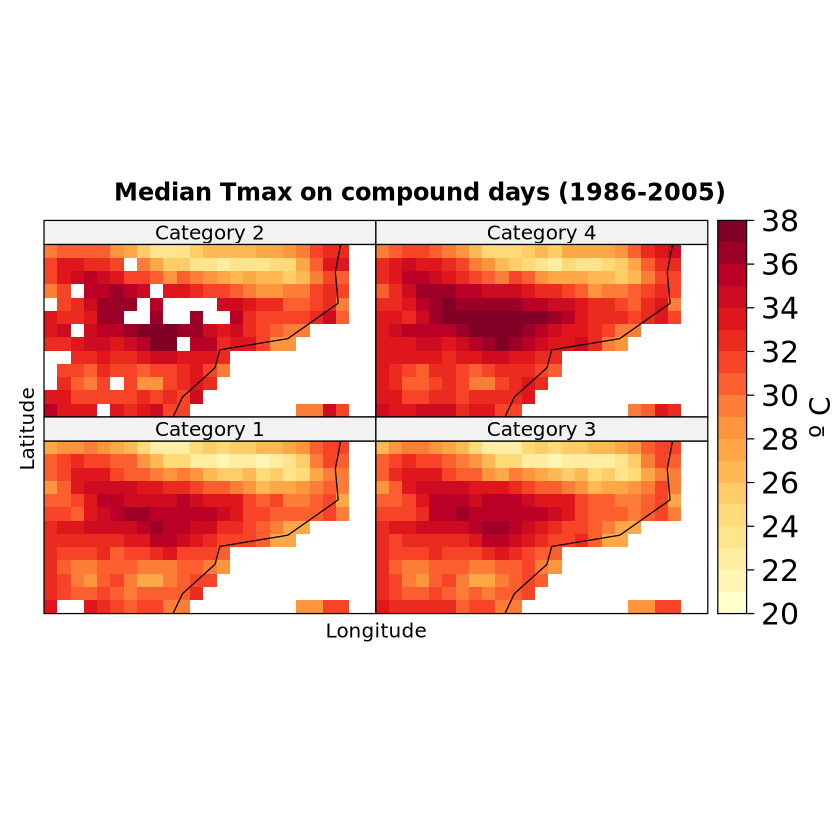

In [16]:
spatialPlot(makeMultiGrid(magnitude$c2, magnitude$c4, magnitude$c1, magnitude$c3),
            backdrop.theme = "coastline", 
            main="Median Tmax on compound days (1986-2005)", 
            as.table=TRUE, names.attr=c("Category 2", "Category 4", "Category 1", "Category 3"),
            color.theme="YlOrRd", set.min=20, set.max=38, at=seq(20, 38, 1),
            xlab="Longitude", ylab="Latitude",
            colorkey = list(space = "right",
                            title = list("º C", cex = 1.4),
                            labels = list(cex = 1.5)))

### Future Projections

In [17]:
pr.isimip.fut <- readRDS("data/pr.rcp8.5.baisimip.rds")
tmax.isimip.fut <- readRDS("data/tasmax.rcp8.5.baisimip.rds")

In [18]:
# Transforming future data
pr.isimip.fut.tf <- transform.data(pr.isimip.fut, hottest.season)
tmax.isimip.fut.tf <- transform.data(tmax.isimip.fut, hottest.season)

In [19]:
source("functions/fun.intensity.hw.hd.R")
intensity.fut <- fun.intensity(pr.obs=pr.isimip.fut.tf, tmax.obs=tmax.isimip.fut.tf, tmax.daily=tmax.isimip.tf)

[2026-06-09 14:23:57.953816] - Computing climatology...



[2026-06-09 14:23:58.090123] - Done.

[2026-06-09 14:23:58.115101] - Computing climatology...

[2026-06-09 14:23:58.194219] - Done.



In [20]:
source("functions/fun.categories.intensity.mean.hw.hd.R")
suppressMessages(
  categories.fut <- fun.categories(intensity.fut)
)

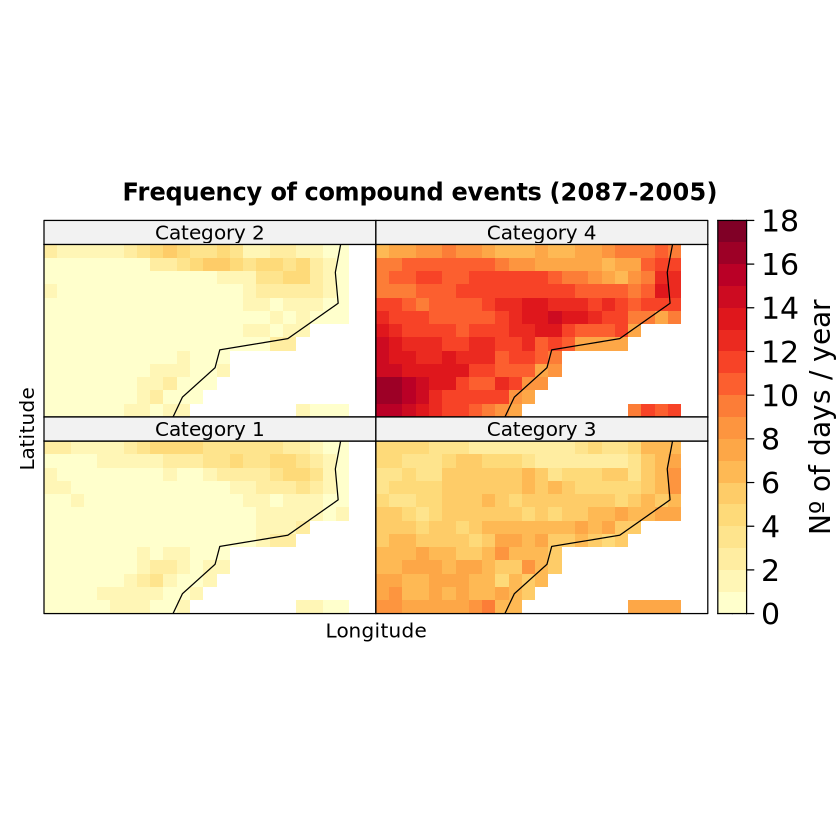

In [21]:
spatialPlot(makeMultiGrid(categories.fut$c2, categories.fut$c4, categories.fut$c1, categories.fut$c3), 
            backdrop.theme = "coastline", 
            main="Frequency of compound events (2087-2005)", 
            as.table=TRUE, names.attr=c("Category 2", "Category 4", "Category 1", "Category 3"),
            color.theme="YlOrRd", set.min=0, set.max=18, at=seq(0,18,1),
            xlab="Longitude", ylab="Latitude",
            colorkey = list(space = "right",
                            title = list("Nº of days / year", cex = 1.4),
                            labels = list(cex = 1.5)))

In [22]:
categories.fut$c1$Data[categories.fut$c1$Data == 0] <- NA
categories.fut$c2$Data[categories.fut$c2$Data == 0] <- NA
categories.fut$c3$Data[categories.fut$c3$Data == 0] <- NA
categories.fut$c4$Data[categories.fut$c4$Data == 0] <- NA 

In [23]:
delta.c1 <- gridArithmetics(categories.fut$c1, categories$c1, operator = "-")
delta.c2 <- gridArithmetics(categories.fut$c2, categories$c2, operator = "-")
delta.c3 <- gridArithmetics(categories.fut$c3, categories$c3, operator = "-")
delta.c4 <- gridArithmetics(categories.fut$c4, categories$c4, operator = "-")

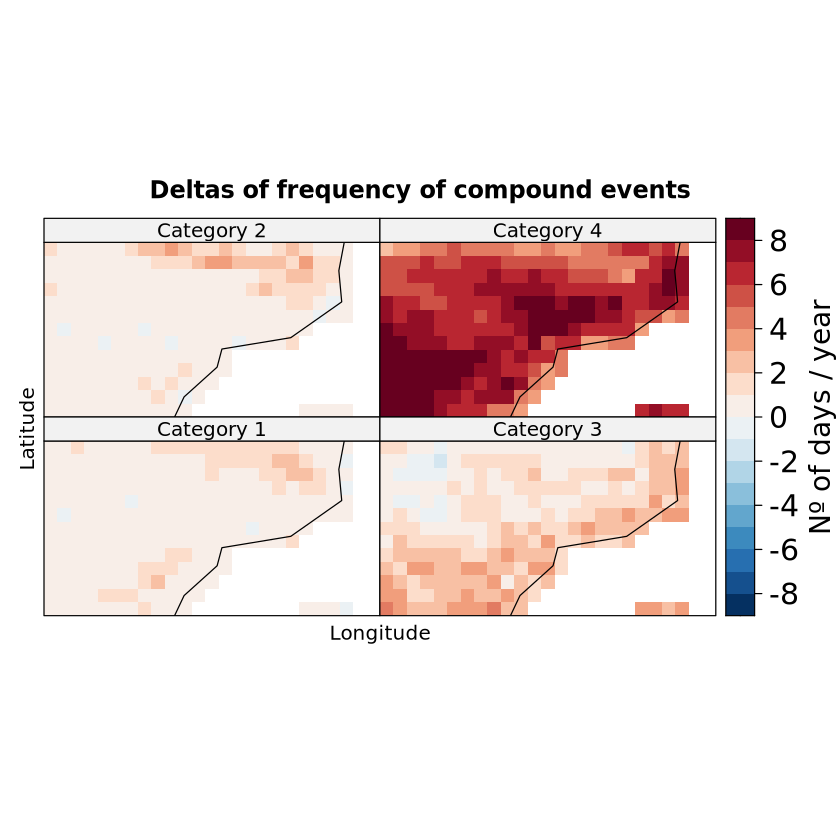

In [24]:
maximum <- round(max(quantile(delta.c1$Data, probs = 0.9, na.rm = TRUE), quantile(delta.c2$Data, probs = 0.9, na.rm = TRUE), 
                     quantile(delta.c3$Data, probs = 0.9, na.rm = TRUE), quantile(delta.c4$Data, probs = 0.9, na.rm = TRUE))) 
spatialPlot(makeMultiGrid(delta.c2, delta.c4, delta.c1, delta.c3), 
            backdrop.theme = "coastline", 
            main="Deltas of frequency of compound events", 
            as.table=TRUE, names.attr=c("Category 2", "Category 4", "Category 1", "Category 3"),
            color.theme="RdBu", rev.colors=TRUE, set.min=-maximum, set.max=maximum, at=seq(-maximum, maximum, 1),
            xlab="Longitude", ylab="Latitude",
            colorkey = list(space = "right",
                            title = list("Nº of days / year", cex = 1.4),
                            labels = list(cex = 1.5)))

In [25]:
source("functions/fun.duration.hw.hd.R")
suppressMessages(
  duration.fut <- d.int(intensity.fut)
)

In [26]:
duration.fut$num$c1$Data[duration.fut$num$c1$Data == 0] <- NA
duration.fut$num$c2$Data[duration.fut$num$c2$Data == 0] <- NA
duration.fut$num$c3$Data[duration.fut$num$c3$Data == 0] <- NA
duration.fut$num$c4$Data[duration.fut$num$c4$Data == 0] <- NA

duration.fut$median$c1$Data[duration.fut$median$c1$Data == 0] <- NA
duration.fut$median$c2$Data[duration.fut$median$c2$Data == 0] <- NA
duration.fut$median$c3$Data[duration.fut$median$c3$Data == 0] <- NA
duration.fut$median$c4$Data[duration.fut$median$c4$Data == 0] <- NA

In [27]:
delta.num.c1 <- gridArithmetics(duration.fut$num$c1, duration$num$c1, operator = "-")
delta.num.c2 <- gridArithmetics(duration.fut$num$c2, duration$num$c2, operator = "-")
delta.num.c3 <- gridArithmetics(duration.fut$num$c3, duration$num$c3, operator = "-")
delta.num.c4 <- gridArithmetics(duration.fut$num$c4, duration$num$c4, operator = "-")

[2026-06-09 14:27:52.39312] - Computing climatology...

[2026-06-09 14:27:52.397356] - Done.

[2026-06-09 14:27:52.400486] - Computing climatology...

[2026-06-09 14:27:52.405456] - Done.

[2026-06-09 14:27:52.409151] - Computing climatology...

[2026-06-09 14:27:52.413976] - Done.

[2026-06-09 14:27:52.417567] - Computing climatology...

[2026-06-09 14:27:52.422544] - Done.



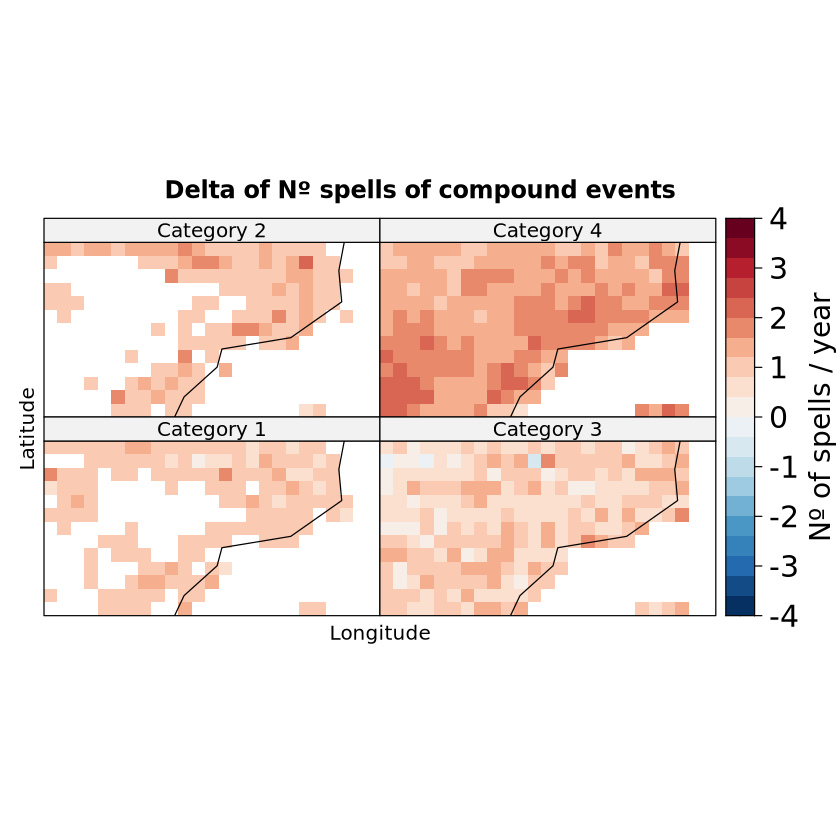

In [28]:
maximum <- round(max(quantile(delta.num.c1$Data, probs = 0.9, na.rm = TRUE), quantile(delta.num.c2$Data, probs = 0.9, na.rm = TRUE), 
                     quantile(delta.num.c3$Data, probs = 0.9, na.rm = TRUE), quantile(delta.num.c4$Data, probs = 0.9, na.rm = TRUE))) 
spatialPlot(makeMultiGrid(climatology(delta.num.c2), climatology(delta.num.c4), climatology(delta.num.c1), climatology(delta.num.c3)), 
            backdrop.theme = "coastline", 
            main="Delta of Nº spells of compound events", 
            as.table=TRUE, names.attr=c("Category 2", "Category 4", "Category 1", "Category 3"),
            color.theme="RdBu", rev.colors=TRUE, set.min=-maximum, set.max=maximum, at=seq(-maximum, maximum, 0.4),
            xlab="Longitude", ylab="Latitude",
            colorkey = list(space = "right",
                            title = list("Nº of spells / year", cex = 1.4),
                            labels = list(cex = 1.5)))

In [29]:
delta.dur.c1 <- gridArithmetics(duration.fut$median$c1, duration$median$c1, operator = "-")
delta.dur.c2 <- gridArithmetics(duration.fut$median$c2, duration$median$c2, operator = "-")
delta.dur.c3 <- gridArithmetics(duration.fut$median$c3, duration$median$c3, operator = "-")
delta.dur.c4 <- gridArithmetics(duration.fut$median$c4, duration$median$c4, operator = "-")

[2026-06-09 14:27:53.028598] - Computing climatology...

[2026-06-09 14:27:53.039898] - Done.

[2026-06-09 14:27:53.04459] - Computing climatology...

[2026-06-09 14:27:53.04946] - Done.

[2026-06-09 14:27:53.053595] - Computing climatology...

[2026-06-09 14:27:53.058759] - Done.

[2026-06-09 14:27:53.062831] - Computing climatology...

[2026-06-09 14:27:53.067659] - Done.



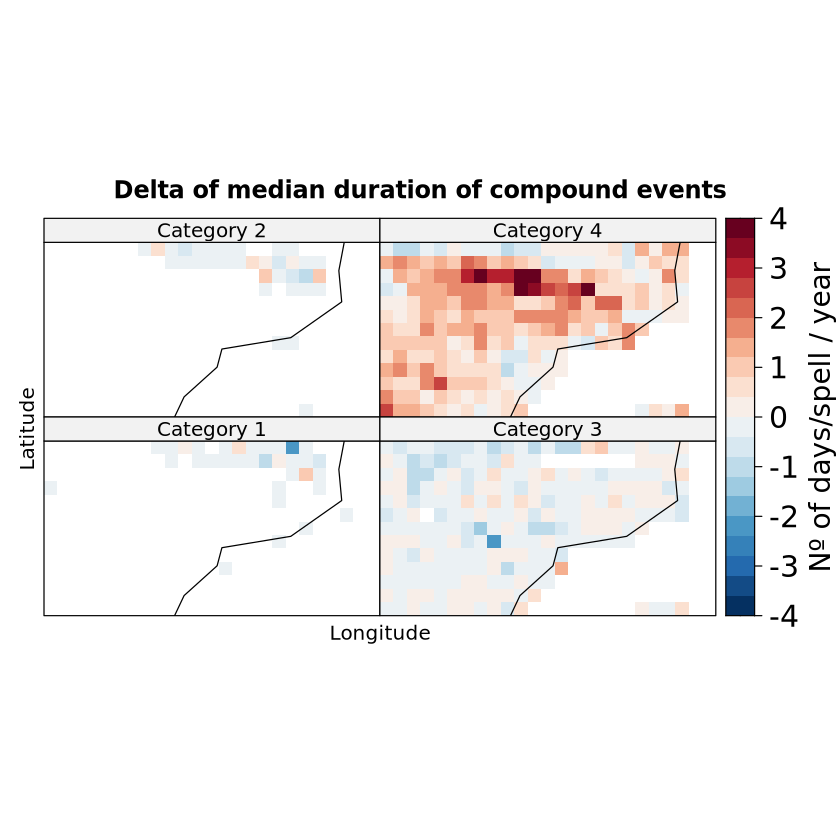

In [30]:
maximum <- round(max(quantile(delta.dur.c1$Data, probs = 0.9, na.rm = TRUE), quantile(delta.dur.c2$Data, probs = 0.9, na.rm = TRUE), 
                     quantile(delta.dur.c3$Data, probs = 0.9, na.rm = TRUE), quantile(delta.dur.c4$Data, probs = 0.9, na.rm = TRUE))) 
spatialPlot(makeMultiGrid(climatology(delta.dur.c2), climatology(delta.dur.c4), climatology(delta.dur.c1), climatology(delta.dur.c3)), 
            backdrop.theme = "coastline", 
            main="Delta of median duration of compound events", 
            as.table=TRUE, names.attr=c("Category 2", "Category 4", "Category 1", "Category 3"),
            color.theme="RdBu", rev.colors=TRUE, set.min=-maximum, set.max=maximum, at=seq(-maximum, maximum, 0.4),
            xlab="Longitude", ylab="Latitude",
            colorkey = list(space = "right",
                            title = list("Nº of days/spell / year", cex = 1.4),
                            labels = list(cex = 1.5)))

In [31]:
source("functions/fun.magnitude.R")
magnitude.fut <- fun.magnitude(intensity.fut, tmax.isimip.fut.tf)

[2026-06-09 14:27:56.666776] - Computing climatology...

[2026-06-09 14:27:56.695758] - Done.

[2026-06-09 14:27:56.708351] - Computing climatology...

[2026-06-09 14:27:56.74928] - Done.

[2026-06-09 14:27:56.762499] - Computing climatology...

[2026-06-09 14:27:56.794175] - Done.

[2026-06-09 14:27:56.810811] - Computing climatology...

[2026-06-09 14:27:56.849944] - Done.



In [32]:
delta.mag.c1 <- gridArithmetics(magnitude.fut$c1, magnitude$c1, operator = "-")
delta.mag.c2 <- gridArithmetics(magnitude.fut$c2, magnitude$c2, operator = "-")
delta.mag.c3 <- gridArithmetics(magnitude.fut$c3, magnitude$c3, operator = "-")
delta.mag.c4 <- gridArithmetics(magnitude.fut$c4, magnitude$c4, operator = "-")

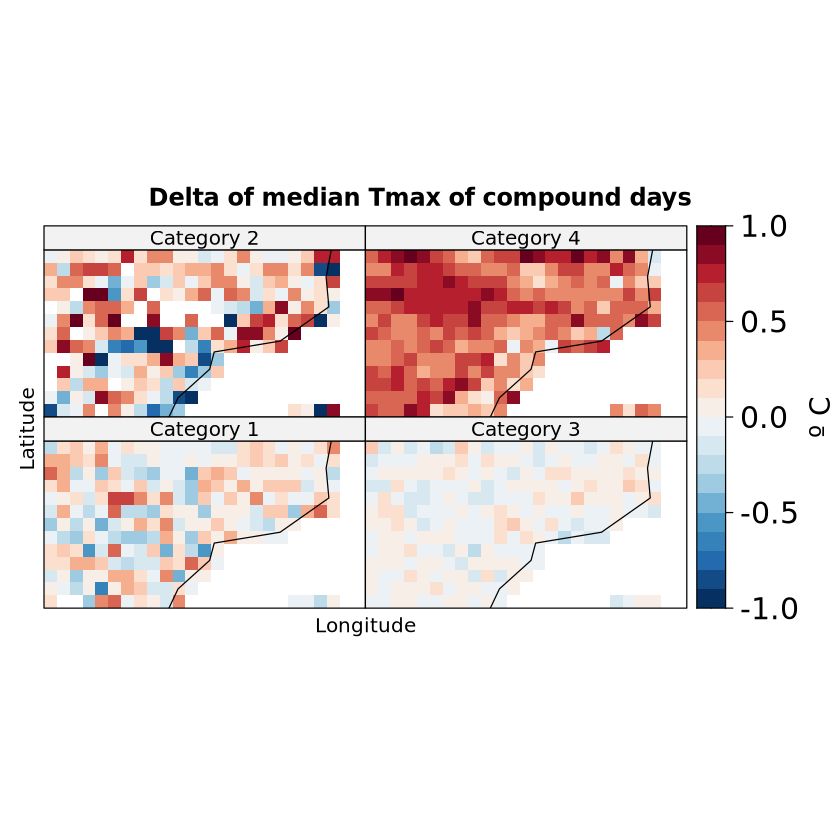

In [33]:
maximum <- round(max(quantile(delta.mag.c1$Data, probs = 0.9, na.rm = TRUE), quantile(delta.mag.c2$Data, probs = 0.9, na.rm = TRUE), 
                     quantile(delta.mag.c3$Data, probs = 0.9, na.rm = TRUE), quantile(delta.mag.c4$Data, probs = 0.9, na.rm = TRUE))) 
spatialPlot(makeMultiGrid(delta.mag.c2, delta.mag.c4, delta.mag.c1, delta.mag.c3), 
            backdrop.theme = "coastline", 
            main="Delta of median Tmax of compound days", 
            as.table=TRUE, names.attr=c("Category 2", "Category 4", "Category 1", "Category 3"),
            color.theme="RdBu", rev.colors=TRUE, set.min=-maximum, set.max=maximum, at=seq(-maximum, maximum, 0.1),
            xlab="Longitude", ylab="Latitude",
            colorkey = list(space = "right",
                            title = list("º C", cex = 1.4),
                            labels = list(cex = 1.5)))

Note: Areas where is are white gridboxes is because no compound events are detected or the condition of two compound days in the spells related metrics is not reached